In [1]:
from deep_kolmogorov import modeling, pdes, trainer
import torch

# model = modeling.KolmogorovNet(modeling.DeepONet(1,{"size_t_s_u": [1,1,3], "num_depth" : 6, "num_width" : 55}), pdes.BSr())
# path = "./exp/avg_bs_r_2023_10_02_00_58_02/Trainer_2023-10-02_00-58-02/Trainer_aed00_00005_5_num_depth=6,num_width=55,seed=0_2023-10-02_00-58-02/checkpoint_000030"
# model.net.load_state_dict(torch.load(f"{path}/model.pth", map_location=torch.device('cuda')))

In [2]:
config={
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_r",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 2000,
  "net": "DeepONet",
  "norm_layer": "layernorm",
  "num_depth": 7,
  "num_width": 75,
  "opt": "adamw",
  "pde": "BSr",
  "seed": 0,
  "size_t_x_u": [
    1,
    1,
    3
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_r_2023_11_08_21_47_16/Trainer_2023-11-08_21-47-16/Trainer_5467d_00005_5_num_depth=7,num_width=75,seed=0_2023-11-08_21-47-16/checkpoint_000023/model.pth"
mytrainer.load_checkpoint(path)


/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

In [3]:
scores_test = mytrainer._test_greeks_loop(greeks=[ "vega"], method="finidiff", d= 0.05)
scores_test["vega"]["current"]

{'time': 0.042237043380737305,
 'steps': 1,
 'overall time': 0.042237043380737305,
 'overall steps': 1.0,
 'mse': 0.028523927554488182,
 'L2^2': 0.009939189068973064,
 'mae': 0.09725750982761383,
 'L1': 0.04791703447699547,
 'L1_std': 0.08742545545101166,
 'L2': 0.09969548168785315}

In [4]:
scores_test = mytrainer._test_greeks_loop(greeks=["delta"], method="finidiff", d= 0.5)
scores_test["delta"]["current"]

{'time': 0.027057170867919922,
 'steps': 1,
 'overall time': 0.027057170867919922,
 'overall steps': 1.0,
 'mse': 0.0002355362958041951,
 'L2^2': 0.00011109548358945176,
 'mae': 0.008113734424114227,
 'L1': 0.005306934472173452,
 'L1_std': 0.00910673476755619,
 'L2': 0.010540184229388582}

In [5]:
scores_test = mytrainer._test_greeks_loop(greeks=["delta", "vega"], method="autodiff")
scores_test["vega"]["current"]

{'time': 0.06006598472595215,
 'steps': 1,
 'overall time': 0.06006598472595215,
 'overall steps': 1.0,
 'mse': 0.1580323427915573,
 'L2^2': 0.05660097301006317,
 'mae': 0.24192486703395844,
 'L1': 0.11108893901109695,
 'L1_std': 0.21038201451301575,
 'L2': 0.23790958999179326}

In [6]:
scores_test["delta"]["current"]

{'time': 0.06005454063415527,
 'steps': 1,
 'overall time': 0.06005454063415527,
 'overall steps': 1.0,
 'mse': 0.002098207827657461,
 'L2^2': 0.0008500273688696325,
 'mae': 0.027274280786514282,
 'L1': 0.017655137926340103,
 'L1_std': 0.023201897740364075,
 'L2': 0.029155228842690166}

In [26]:
for batch in mytrainer.test_loader:
    batch = {_k: _v[batch["t"]>0].reshape(-1,1) for _k,_v in batch.items()}
    batch = {k: v.to("cuda") for k, v in batch.items()}  # 将 batch 中的所有数据移动到相同设备
    res = mytrainer.model.module.test_greeks(batch, greeks=["delta","vega"], method="finidiff", d=0.05)


In [27]:
_para = "sigma"
batch[_para] = batch[_para].clone().detach().requires_grad_(True)
batch_flat = mytrainer.pde.normalize_and_flatten(batch)
mytrainer.net.eval()
pred = mytrainer.net(batch_flat)
pred.backward(torch.ones_like(batch[_para]))
testres = batch[_para].grad

In [28]:
testres

tensor([[0.5009],
        [2.1325],
        [3.0659],
        ...,
        [3.7572],
        [2.1644],
        [1.9230]], device='cuda:0')

In [29]:
res["pde"]["vega"]

tensor([[2.9817],
        [2.1737],
        [2.6557],
        ...,
        [3.4385],
        [2.0790],
        [1.7353]], device='cuda:0')

In [30]:
(abs(res["pde"]["vega"]-testres)/(1+res["pde"]["vega"])).mean()
# (abs(res["pde"]["vega"]-res["net"]["vega"])/(1+res["pde"]["vega"])).mean()

tensor(0.0874, device='cuda:0')

In [23]:
(abs(res["pde"]["delta"]-testres)/(1+res["pde"]["delta"])).mean()
# (abs(res["pde"]["vega"]-res["net"]["vega"])/(1+res["pde"]["vega"])).mean()

tensor(0.0177, device='cuda:0')

In [68]:
res["pde"]["vega"].mean()

tensor(1.6661, device='cuda:0')

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

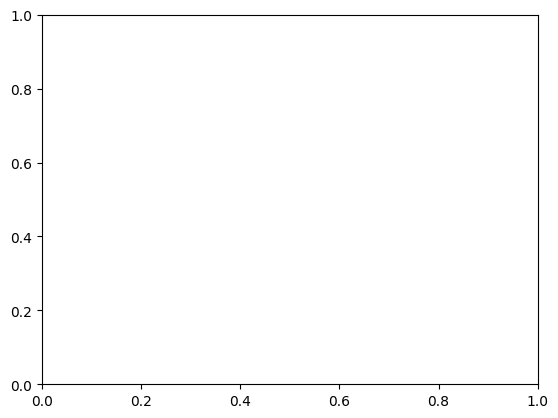

In [47]:
import matplotlib.pyplot as plt

plt.scatter(res["net"]["delta"].cpu(),res["pde"]["delta"].cpu())
# plt.hist(res["pde"]["delta"][:200].cpu())

In [110]:
a = {1:2,2:3}

In [114]:
2 not in a

False

In [2]:
torch.zeros(3,4)

NameError: name 'torch' is not defined

In [25]:
mytrainer.test_loader = mytrainer.pde.dataloader(120000, 1, 'test', True)